### 1. Import necessary libraries

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings(action ="ignore")

### 2. Import DataSet


In [4]:
cars_data = pd.read_csv(filepath_or_buffer = "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


### 3. Data Understand

##### 3.1 perfrom initial investigation on the data

In [9]:
cars_data.shape

(81, 5)

In [10]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [11]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [12]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Now let's check  for the assumption

### Test 1 : Linearity test

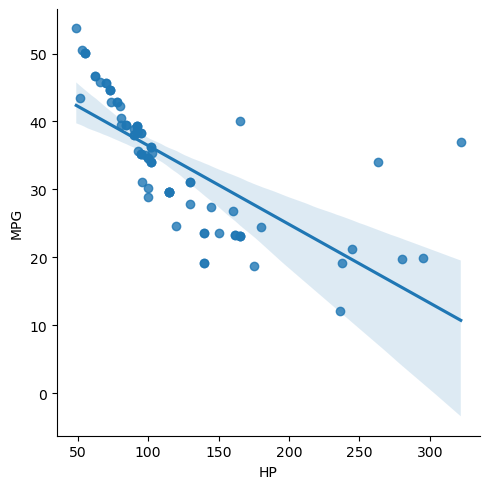

In [13]:
sns.lmplot(data=cars_data,x="HP",y="MPG",)

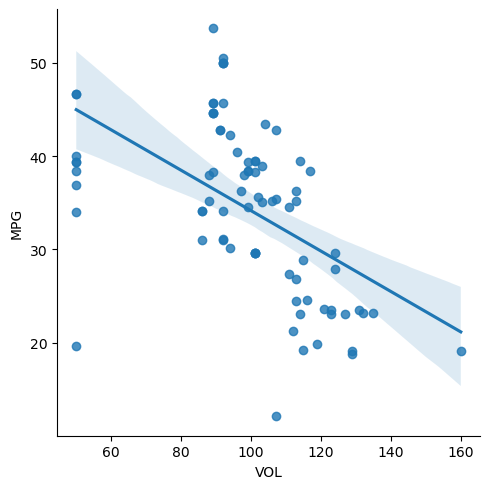

In [14]:
sns.lmplot(data=cars_data,x="VOL",y="MPG",)

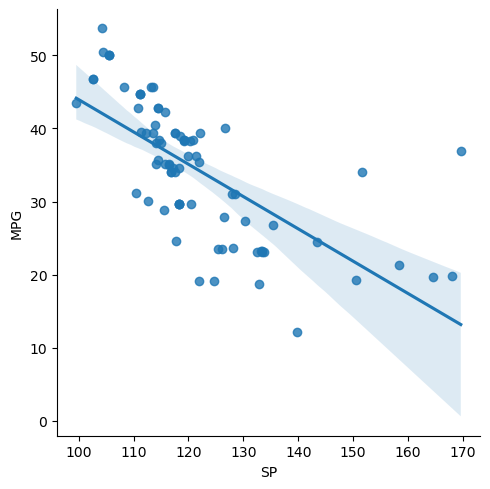

In [15]:
sns.lmplot(data=cars_data,x="SP",y="MPG",)

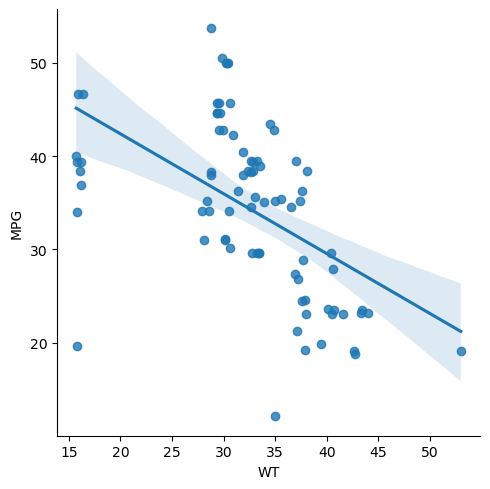

In [16]:
sns.lmplot(data=cars_data,x="WT",y="MPG",)

#### Test 1 - Linearity test failed

### Test 2 - Normality Test

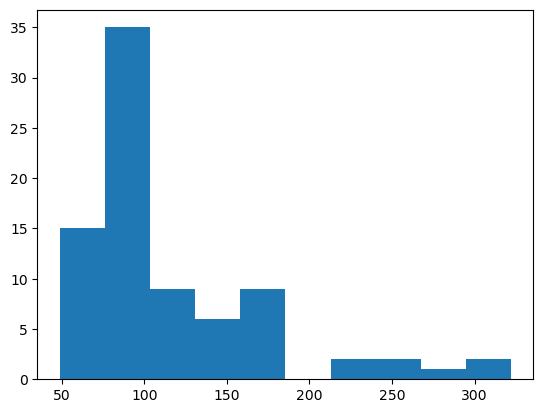

In [17]:
plt.hist(cars_data["HP"])
plt.show()

<Axes: ylabel='Density'>

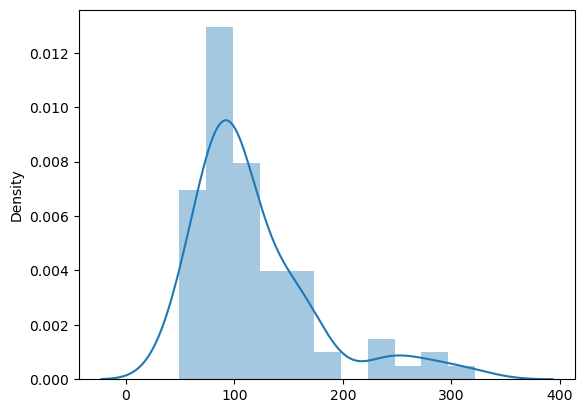

In [18]:
sns.distplot(x=cars_data["HP"])

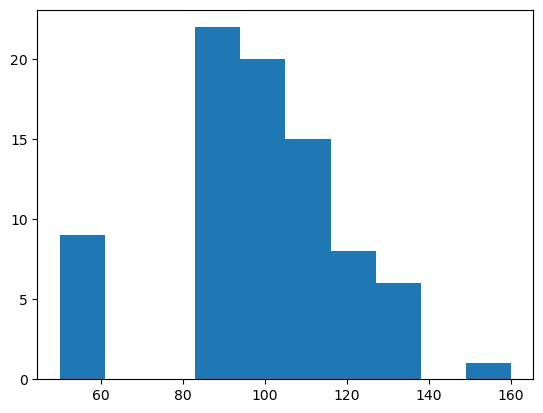

In [19]:
plt.hist(cars_data["VOL"])
plt.show()

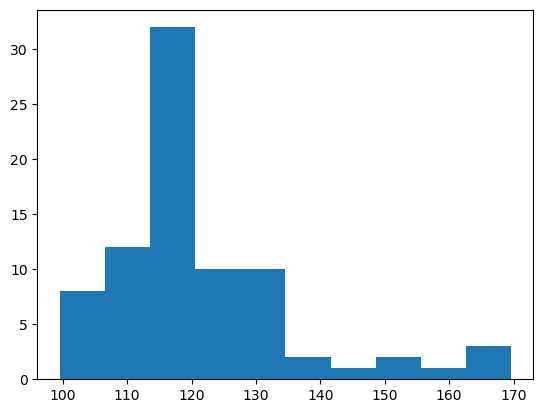

In [20]:
plt.hist(cars_data["SP"])
plt.show()

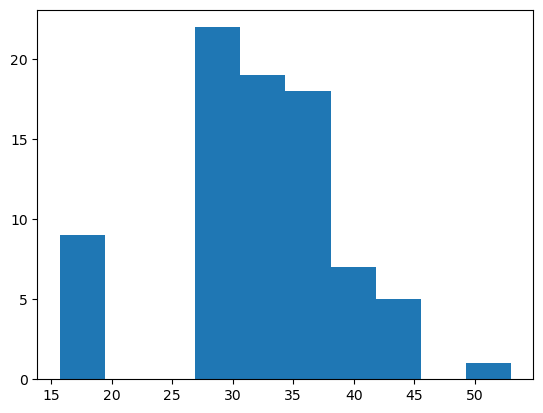

In [21]:
plt.hist(cars_data["WT"])
plt.show()

Test 2 Normailty teat also failed

### Test 3 - Multicollinearity Test

In [22]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


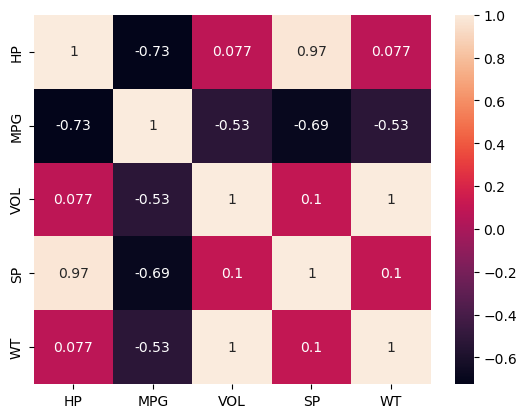

In [23]:
sns.heatmap(data = corr_matrix,annot=True)
plt.show()

##### Test 3 - There is Multicollinearity in the data

### Test 4 - AutoRegression test is passed

### 4. Data Preparation

In [24]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [25]:
x = cars_data[['HP','VOL','SP','WT']]
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [26]:
y = cars_data['MPG']
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

#### There is nothing to prepare because all feature is numeric

### 5. Model Building

In [27]:
linear_model = LinearRegression()

### 6. Model Traning

In [28]:
linear_model.fit(x,y)

LinearRegression()

In [29]:
linear_model.intercept_

30.67733585215172

In [30]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

### 7. Model Testing

In [31]:
y_predict = linear_model.predict(x)
y_predict

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

### 8. Model Evaluation

In [32]:
error = y-y_predict
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [60]:
error.mean()

-3.991320305812909e-15

In [63]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [44]:
mean_absolute_error(y,y_predict)   # Same unit

3.267968285420799

In [45]:
mean_squared_error(y,y_predict)    # Squared output unit

18.897141152343096

In [46]:
r2_score(y,y_predict)

0.7705372737359844

### Ro see adjusted R2 score, We are using OLS technique from statsModels Formula

In [47]:
import statsmodels.formula.api as smf

In [48]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [50]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()

In [57]:
print("R2 score :",linear_stats_model.rsquared.round(4),"\nAdjust R2 score :", linear_stats_model.rsquared_adj.round(4))

R2 score : 0.7705 
Adjust R2 score : 0.7585


In [65]:
linear_stats_model = smf.ols(formula = "MPG ~ HP", data = cars_data).fit()

In [66]:
print("R2 score :",linear_stats_model.rsquared.round(4),"\nAdjust R2 score :", linear_stats_model.rsquared_adj.round(4))

R2 score : 0.5257 
Adjust R2 score : 0.5197


In [67]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL", data = cars_data).fit()

In [68]:
print("R2 score :",linear_stats_model.rsquared.round(4),"\nAdjust R2 score :", linear_stats_model.rsquared_adj.round(4))

R2 score : 0.7507 
Adjust R2 score : 0.7443


In [69]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP", data = cars_data).fit()

In [70]:
print("R2 score :",linear_stats_model.rsquared.round(4),"\nAdjust R2 score :", linear_stats_model.rsquared_adj.round(4))

R2 score : 0.7704 
Adjust R2 score : 0.7614


In [71]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()

In [72]:
print("R2 score :",linear_stats_model.rsquared.round(4),"\nAdjust R2 score :", linear_stats_model.rsquared_adj.round(4))

R2 score : 0.7705 
Adjust R2 score : 0.7585


In [49]:
cars_data["error"] = error
cars_data

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


### Let's now perfrom Test 5 : Homoscedasticity test 

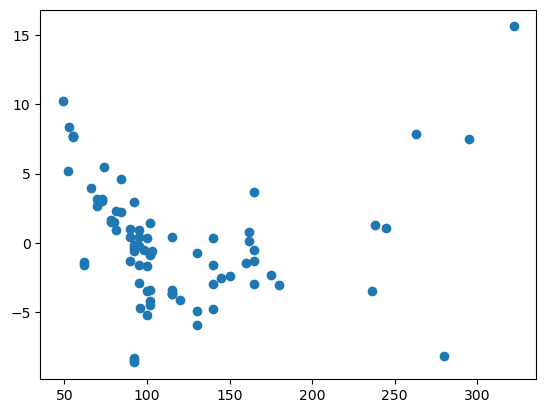

In [51]:
plt.scatter(data = cars_data,x = "HP",y= "error")
plt.show()

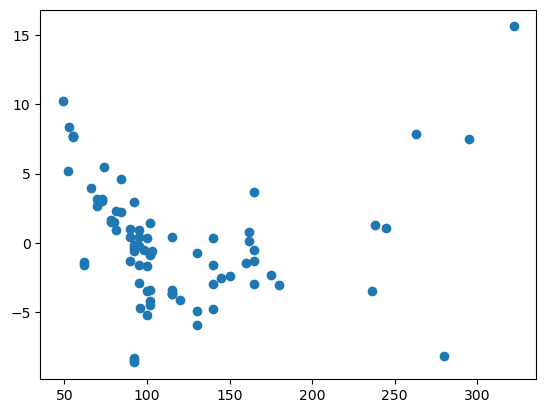

In [52]:
plt.scatter(data = cars_data,x = "HP",y= "error")
plt.show()

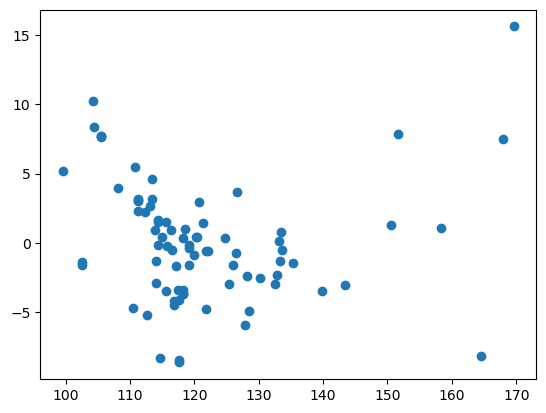

In [53]:
plt.scatter(data = cars_data,x = "SP",y= "error")
plt.show()

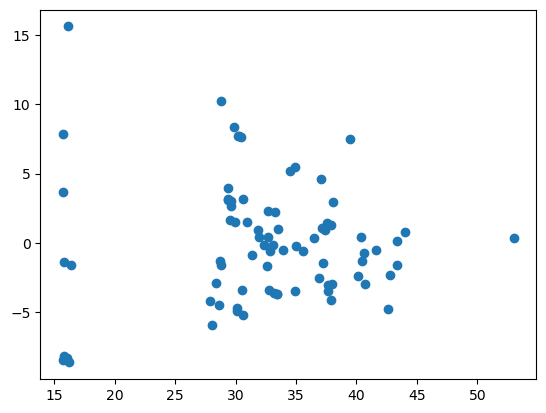

In [54]:
plt.scatter(data = cars_data,x = "WT",y= "error")
plt.show()

##### Test 5 Homoscedasticity test is failed

### Test 6 : Zero Residual Mean Test

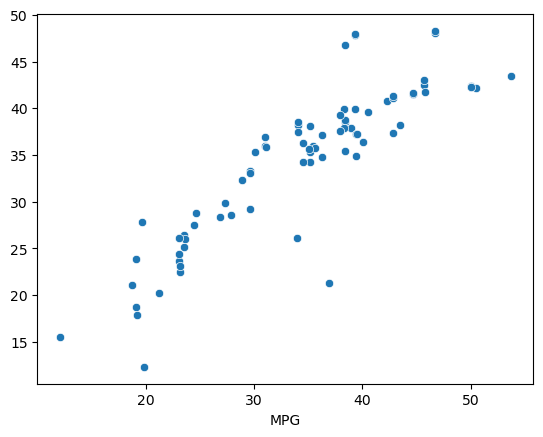

In [55]:
sns.scatterplot(x=cars_data["MPG"], y=y_predict)
plt.show()

#### Test 6: Zero Residual mean test is also failed

### 9. Model deployment

In [56]:
from pickle import dump

In [57]:
dump(obj = linear_model,file = open(file = "linear_intelligence_file.pkl",mode='wb'))

In [58]:
from pickle import load

In [60]:
linear_intel_pkl = load(file = open(file = "linear_intelligence_file.pkl",mode='rb'))
linear_intel_pkl

LinearRegression()

In [62]:
linear_intel_pkl.predict(x)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

#### THE END
